#**CASE-1** Regresyon

Konu: NuScale US600 isimli küçük modüler nükleer reaktörün (SMR) yakıt çubuklarına ait simülasyon sonuçları.

Nasıl Üretilmiş: Fiziksel bir reaktörden değil; nükleer fizikte standart olan MCNP6 adlı bir Monte Carlo simülasyon programı çalıştırılarak üretilmiş.

Ne Değiştirilmiş: Yakıt çubuklarındaki Uranyum-235 zenginleştirme oranları (%0.7 ile %5.0 arasında) rastgele/düzgün olarak değiştirilmiş.

In [ ]:
import random
import platform
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")

SEED=42
random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid",context ="notebook")
plt.rcParams["figure.figsize"]=(7,4)
plt.rcParams["figure.dpi"] = 110


print(f"python: {sys.version.split()[0]}")
print(f"Platform:{platform.platform()}")
print(f"seaborn: {sns.__version__}")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"sklearn: {sklearn.__version__}")

python: 3.13.15
Platform:Linux-6.6.122+-x86_64-with-glibc2.39
seaborn: 0.13.2
pandas: 2.2.3
numpy: 2.1.3
sklearn: 1.6.1


In [ ]:
#sımdı dosyamızı okuyacagım
df_raw = pd.read_csv("raw.csv", sep=r"\s+", header=None)
df_test = pd.read_csv("test.csv", sep=r"\s+", header=None)
#okuyup okumadıgını test etmek ıcın boyutlarına bakacagım
print(df_raw.shape)
print(df_test.shape)

(24000, 41)
(360, 41)


In [ ]:
print(df_raw.columns)

Index([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40],
      dtype='int64')


In [ ]:
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24000 entries, 0 to 23999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       24000 non-null  float64
 1   1       24000 non-null  float64
 2   2       24000 non-null  float64
 3   3       24000 non-null  float64
 4   4       24000 non-null  float64
 5   5       24000 non-null  float64
 6   6       24000 non-null  float64
 7   7       24000 non-null  float64
 8   8       24000 non-null  float64
 9   9       24000 non-null  float64
 10  10      24000 non-null  float64
 11  11      24000 non-null  float64
 12  12      24000 non-null  float64
 13  13      24000 non-null  float64
 14  14      24000 non-null  float64
 15  15      24000 non-null  float64
 16  16      24000 non-null  float64
 17  17      24000 non-null  float64
 18  18      24000 non-null  float64
 19  19      24000 non-null  float64
 20  20      24000 non-null  float64
 21  21      24000 non-null  float64
 22

In [ ]:
# Girdiler (X): 2. sütundan 40. sütuna kadar olan 39 yakıt çubuğu
Xr_train = df_raw.iloc[:, 2:]
Xr_test  = df_test.iloc[:, 2:]

# Hedef (y): 0. sütundaki k-inf değeri
yr_train = df_raw.iloc[:, 0]
yr_test  = df_test.iloc[:, 0]

print("Train X:", Xr_train.shape, "| Train y:", yr_train.shape)
print("Test X :", Xr_test.shape, "| Test y :", yr_test.shape)

Train X: (24000, 39) | Train y: (24000,)
Test X : (360, 39) | Test y : (360,)


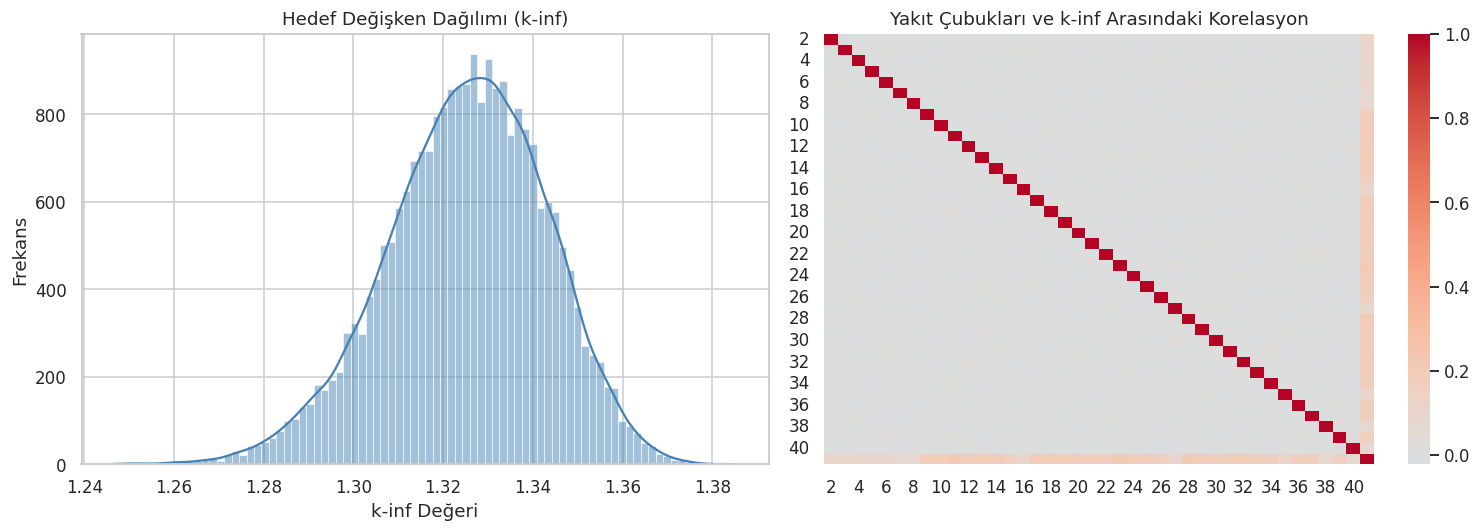

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Sol Grafik: Nükleer hedef değişken dağılımı (k-inf)
sns.histplot(yr_train, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Hedef Değişken Dağılımı (k-inf)")
axes[0].set_xlabel("k-inf Değeri")
axes[0].set_ylabel("Frekans")

# 2. Sağ Grafik: 39 Yakıt Çubuğu ve Hedef Arasındaki Korelasyon Haritası
# Özellikler ile hedefi yan yana birleştirip korelasyon matrisi çıkarıyoruz
corr = pd.concat([Xr_train, yr_train.rename("k_inf")], axis=1).corr()

# 40 sütun olduğu için annot=False yaptık (renkler ilişkileri net gösterir)
sns.heatmap(
    corr,
    annot=False,
    cmap="coolwarm",
    center=0,
    ax=axes[1],
    cbar=True,  # Renk skalasını görmek için barı açtık
)
axes[1].set_title("Yakıt Çubukları ve k-inf Arasındaki Korelasyon")

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Modelleri Train verisi ile eğit
baseline = DummyRegressor(strategy="mean").fit(Xr_train, yr_train)
linear = LinearRegression().fit(Xr_train, yr_train)


# 2. Değerlendirme fonksiyonunu tanımla
def regresyon_raporu(model, X, y, ad):
  tahmin = model.predict(X)
  return {
      "Model": ad,
      "Mae": mean_absolute_error(y, tahmin),
      "mse": mean_squared_error(y, tahmin),
      "rmse": np.sqrt(mean_squared_error(y, tahmin)),
      "r2": r2_score(y, tahmin),
  }


# 3. Sonuçları DataFrame olarak birleştir
sonuc = pd.DataFrame([
    regresyon_raporu(baseline, Xr_train, yr_train, "Baseline"),
    regresyon_raporu(linear, Xr_test, yr_test, "Linear"),
]).set_index("Model").round(3)

sonuc

,Mae,mse,rmse,r2
Model,,,,
Baseline,0.014,0.0,0.018,0.000
Linear,0.002,0.0,0.002,0.987


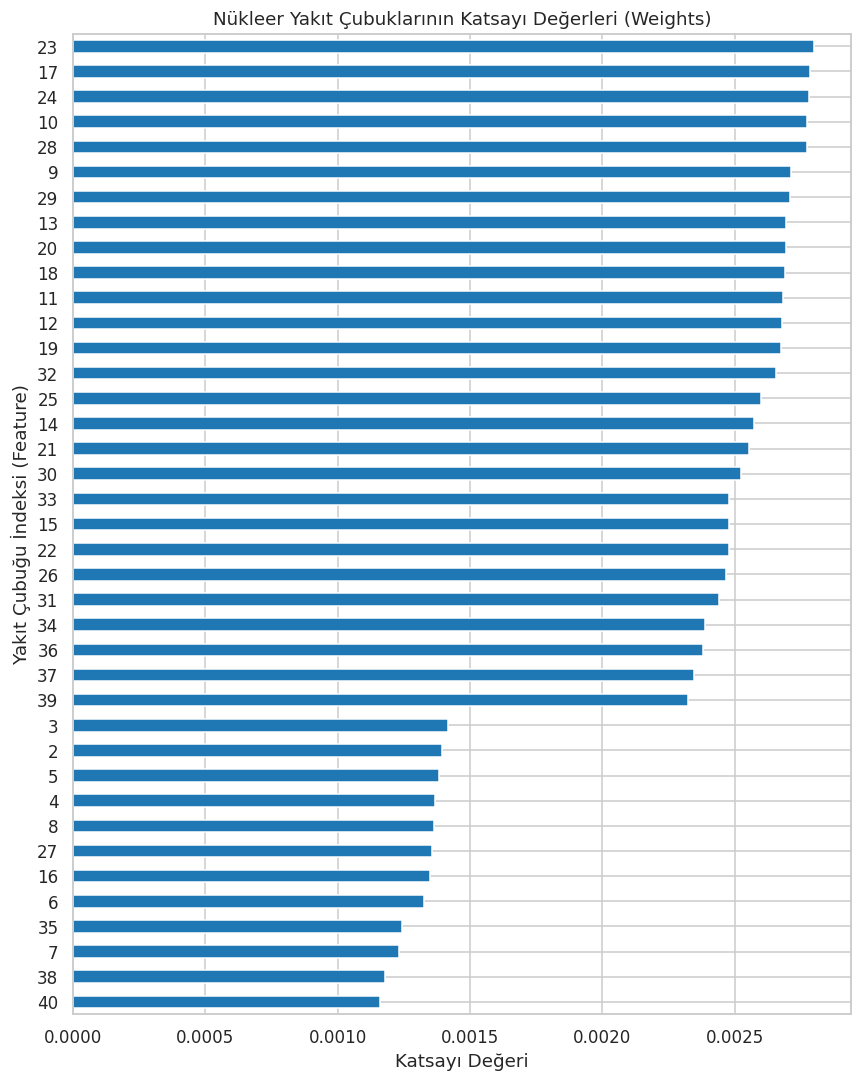

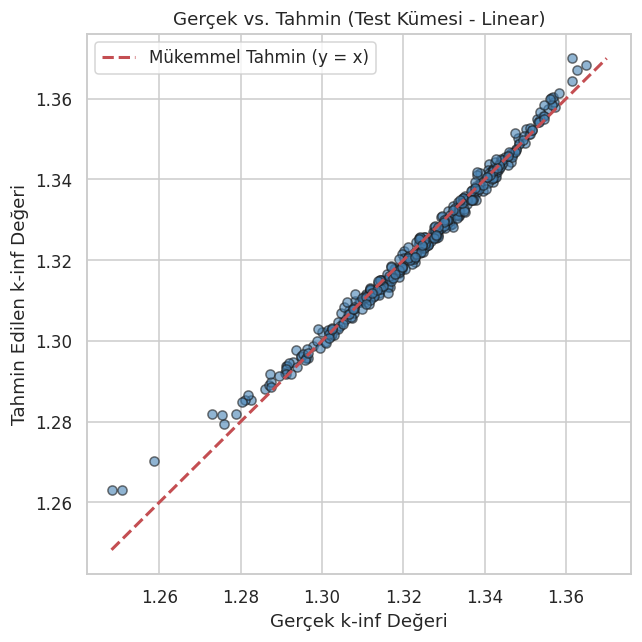

In [ ]:
katsayilar = pd.Series(linear.coef_, index=Xr_train.columns).sort_values()

# 39 özellik sığsın diye boyutu (8, 10) yaptık
plt.figure(figsize=(8, 10))
katsayilar.plot(
    kind="barh", color=np.where(katsayilar > 0, "tab:blue", "tab:red")
)
plt.title("Nükleer Yakıt Çubuklarının Katsayı Değerleri (Weights)")
plt.xlabel("Katsayı Değeri")
plt.ylabel("Yakıt Çubuğu İndeksi (Feature)")
plt.tight_layout()
plt.show()


tahmin = linear.predict(Xr_test)

plt.figure(figsize=(6, 6))
plt.scatter(yr_test, tahmin, alpha=0.6, color="steelblue", edgecolors="k")

# Mükemmel tahmin çizgisi (45 derecelik referans doğrusu)
lim = [min(yr_test.min(), tahmin.min()), max(yr_test.max(), tahmin.max())]
plt.plot(lim, lim, "r--", linewidth=2, label="Mükemmel Tahmin (y = x)")

plt.xlabel("Gerçek k-inf Değeri")
plt.ylabel("Tahmin Edilen k-inf Değeri")
plt.title("Gerçek vs. Tahmin (Test Kümesi - Linear)")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
print(Xr_train.head(3))

         2         3         4         5         6         7         8   \
0  3.562615  1.112359  4.208065  1.412679  2.271031  3.950614  3.627032   
1  2.354766  1.047929  2.268974  4.637777  3.793194  2.859702  4.361058   
2  3.037997  4.719517  1.502280  3.644736  3.575727  1.337686  2.380347   

         9         10        11  ...        31        32        33        34  \
0  4.600332  2.892000  3.970936  ...  3.965987  4.030999  0.826347  2.088521   
1  3.592485  2.594441  2.890112  ...  2.228000  4.837370  2.846538  3.413201   
2  4.503771  1.334796  0.880913  ...  2.615278  3.757999  3.161658  4.996056   

         35        36        37        38        39        40  
0  4.088550  1.184149  2.780985  2.865400  4.773820  3.539373  
1  4.154079  4.700800  3.597879  4.681148  3.215494  3.972672  
2  3.339642  2.548468  4.417111  1.375554  4.363320  2.988546  

[3 rows x 39 columns]


In [ ]:
from sklearn.linear_model import Lasso, LinearRegression, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

modeller = {
    "Doğrusal": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso": make_pipeline(StandardScaler(), Lasso(alpha=1.0)),
}

satirlar = []

for ad, m in modeller.items():
  m.fit(Xr_train, yr_train)
  satirlar.append(regresyon_raporu(m, Xr_test, yr_test, ad))

pd.DataFrame(satirlar).set_index("Model").round(3)

,Mae,mse,rmse,r2
Model,,,,
Doğrusal,0.002,0.0,0.002,0.987
Ridge,0.002,0.0,0.002,0.987
Lasso,0.015,0.0,0.019,-0.003


In [ ]:
lasso = modeller["Lasso"].named_steps["lasso"]
pd.Series(lasso.coef_, index=Xr_train.columns).round(2).to_frame("Lasso değişkenler").T

,2,3,4,5,6,7,8,9,10,11,...,31,32,33,34,35,36,37,38,39,40
Lasso değişkenler,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
print(modeller.keys())

dict_keys(['Doğrusal', 'Ridge', 'Lasso'])


#**CASE-2 Classification**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

SEED = 42

# 1) Veriyi yükleme işlemi (ayraç noktalı vırgul kullanmıs verıyı okumak ıcın duzgun onu belırtmemız gerekıyor.)
df = pd.read_csv("student-mat.csv", sep=";")

print(df.shape)
display(df.head())
print("Eksik değer:", df.isna().sum().sum())

# 2) Hedef değişkeni üret
df["gecti"] = (df["G3"] >= 10).astype(int)
print(df["gecti"].value_counts())
print(df["gecti"].value_counts(normalize=True).round(3))

# 3) Varyant seçimi: G1/G2 dahil mi?
G1G2_DAHIL = True   # True yapınca A varyantı

atilacak = ["G3", "gecti"] + ([] if G1G2_DAHIL else ["G1", "G2"])
X = df.drop(columns=atilacak)
y = df["gecti"]

# 4) Kategorik sütunları sayıya çevir
X = pd.get_dummies(X, drop_first=True)
print("Özellik sayısı:", X.shape[1])

# 5) Train/test ayır (sınıf oranını koruyarak)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print(Xc_train.shape, Xc_test.shape)

(395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


Eksik değer: 0
gecti
1    265
0    130
Name: count, dtype: int64
gecti
1    0.671
0    0.329
Name: proportion, dtype: float64
Özellik sayısı: 41
(316, 41) (79, 41)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

siniflandiricilar = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "Karar ağacı": DecisionTreeClassifier(random_state=SEED),
    "Rastgele orman": RandomForestClassifier(random_state=SEED)
}

satirlar = []

for ad, m in siniflandiricilar.items():
    m.fit(Xc_train, yc_train)
    satirlar.append({
        "Model": ad,
        "Eğitim": accuracy_score(yc_train, m.predict(Xc_train)),
        "Test": accuracy_score(yc_test, m.predict(Xc_test))
    })

pd.DataFrame(satirlar).set_index("Model").round(3)

,Eğitim,Test
Model,,
Baseline,0.671,0.671
Logistic,0.981,0.886
KNN,0.915,0.848
Karar ağacı,1.000,0.861
Rastgele orman,1.000,0.873


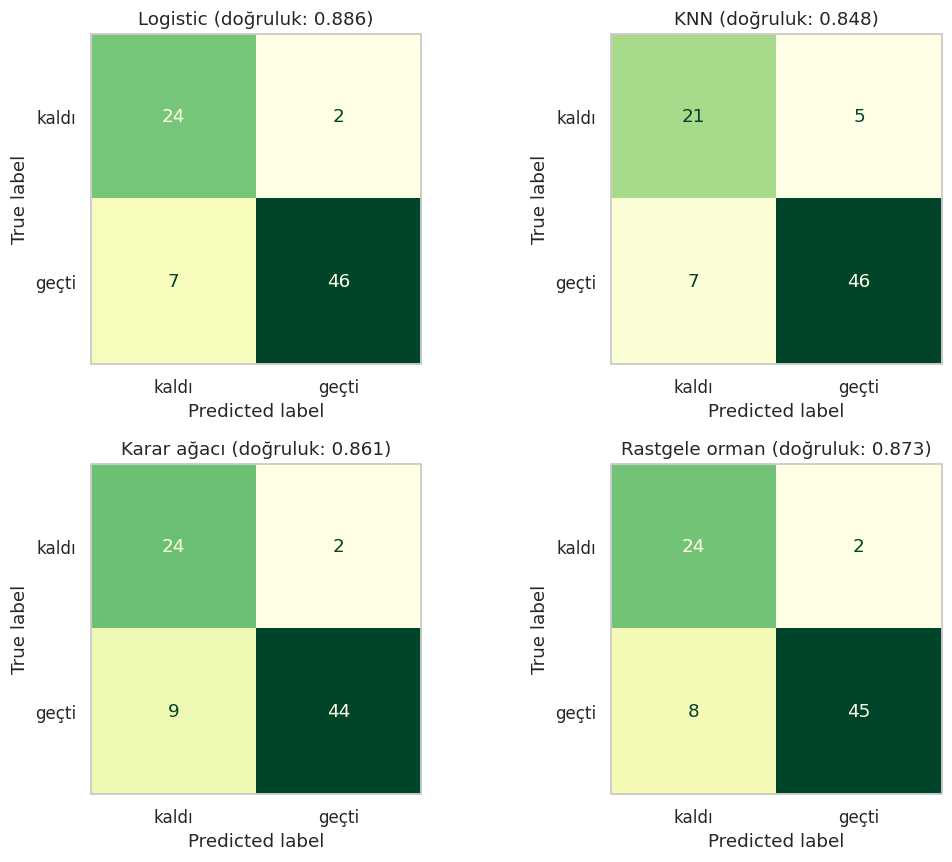

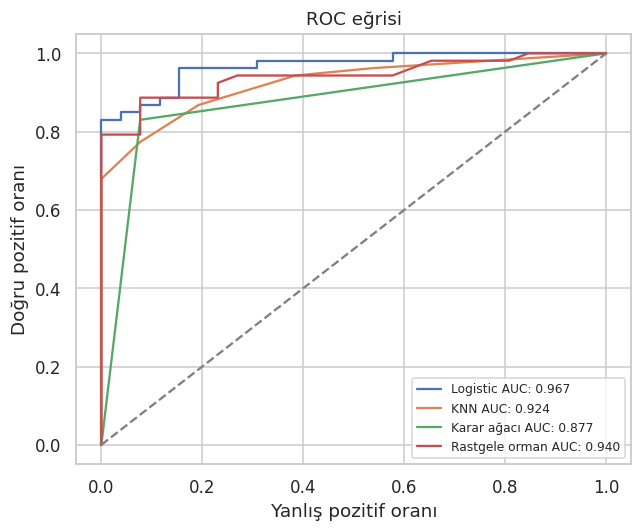

===== Logistic =====
              precision    recall  f1-score   support

       kaldı       0.77      0.92      0.84        26
       geçti       0.96      0.87      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.90      0.88        79
weighted avg       0.90      0.89      0.89        79

===== KNN =====
              precision    recall  f1-score   support

       kaldı       0.75      0.81      0.78        26
       geçti       0.90      0.87      0.88        53

    accuracy                           0.85        79
   macro avg       0.83      0.84      0.83        79
weighted avg       0.85      0.85      0.85        79

===== Karar ağacı =====
              precision    recall  f1-score   support

       kaldı       0.73      0.92      0.81        26
       geçti       0.96      0.83      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.88      0.85        79
weighted avg 

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_curve, roc_auc_score

modeller = ["Logistic", "KNN", "Karar ağacı", "Rastgele orman"]

# 1) 4 modelin karışıklık matrisi (2x2 ızgara)
fig_cm, axes_cm = plt.subplots(2, 2, figsize=(10, 8))

for ax, ad in zip(axes_cm.ravel(), modeller):
    tahmin = siniflandiricilar[ad].predict(Xc_test)
    ConfusionMatrixDisplay.from_predictions(
        yc_test, tahmin,
        display_labels=["kaldı", "geçti"],
        cmap="YlGn", ax=ax, colorbar=False
    )
    ax.set_title(f"{ad} (doğruluk: {accuracy_score(yc_test, tahmin):.3f})")
    ax.grid(False)

plt.tight_layout()
plt.show()

# 2) ROC eğrileri (ayrı şekil, tek kutu)
fig_roc, ax_roc = plt.subplots(figsize=(6, 5))

for ad in modeller:
    p = siniflandiricilar[ad].predict_proba(Xc_test)[:, 1]
    fpr, tpr, _ = roc_curve(yc_test, p)
    ax_roc.plot(fpr, tpr, label=f"{ad} AUC: {roc_auc_score(yc_test, p):.3f}")

ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray")
ax_roc.set_xlabel("Yanlış pozitif oranı")
ax_roc.set_ylabel("Doğru pozitif oranı")
ax_roc.set_title("ROC eğrisi")
ax_roc.legend(fontsize=8)
ax_roc.grid(True)

plt.tight_layout()
plt.show()

# 3) Her model için classification_report
for ad in modeller:
    tahmin = siniflandiricilar[ad].predict(Xc_test)
    print(f"===== {ad} =====")
    print(classification_report(yc_test, tahmin, target_names=["kaldı", "geçti"]))

In [ ]:
#Veriyi parçalara bölüyor ve her turda farklı bir parçayı test yapıp modeli baştan eğitiyor.
#cross_val_score her turda modeli sıfırdan eğitiyor. 5 parçalı CV ile her model için 5 kez eğitim yapılıyor. Senin sözlüğünde 5 model olduğu için toplam 5 × 5 = 25 eğitim oluyor.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

satirlar = []

for ad, m in siniflandiricilar.items():
    skorlar = cross_val_score(m, Xc_train, yc_train, cv=cv, scoring="accuracy")
    satirlar.append({
        "Model": ad,
        "Ortalama skor": skorlar.mean(),
        "Standart sapma": skorlar.std()
    })

cv_sonuc = pd.DataFrame(satirlar).set_index("Model").sort_values("Ortalama skor", ascending=False).round(3)
display(cv_sonuc)

,Ortalama skor,Standart sapma
Model,,
Logistic,0.943,0.008
Rastgele orman,0.924,0.018
Karar ağacı,0.905,0.036
KNN,0.873,0.029
Baseline,0.671,0.006


In [ ]:
#burada knn ıcın bır nokta secılır ona gore baz alınır buradakı en ıyı k degerı ne onu bulmaya calısıyoruz aslında ve en ıyısınınn accuracy sıne bakıyoruz
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier())

param_grid = {
    "kneighborsclassifier__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 21],
    "kneighborsclassifier__weights": ["uniform", "distance"]
}

opt = GridSearchCV(pipe, param_grid, cv=cv, scoring="accuracy", n_jobs=-1)
opt.fit(Xc_train, yc_train)

print("En iyi parametreler:", opt.best_params_)
print(f"En iyi CV skoru: {opt.best_score_:.3f}")

# Ayarlanmış modeli test setinde dene
print(f"Test accuracy: {opt.score(Xc_test, yc_test):.3f}")

En iyi parametreler: {'kneighborsclassifier__n_neighbors': 11, 'kneighborsclassifier__weights': 'uniform'}
En iyi CV skoru: 0.737
Test accuracy: 0.747
